In [ ]:
#Import packge

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# pip install mlxtend 
from mlxtend.frequent_patterns import apriori, association_rules

In [631]:
#Import Data

df = pd.read_csv(r"C:\Users\DELL\OneDrive\سطح المكتب\DM\bread basket.csv")
df.head()

,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,30-10-2016 09:58,morning,weekend
1,2,Scandinavian,30-10-2016 10:05,morning,weekend
2,2,Scandinavian,30-10-2016 10:05,morning,weekend
3,3,Hot chocolate,30-10-2016 10:07,morning,weekend
4,3,Jam,30-10-2016 10:07,morning,weekend


In [633]:
#Missing Data

df.Item 

0                Bread
1         Scandinavian
2         Scandinavian
3        Hot chocolate
4                  Jam
             ...      
20502           Coffee
20503              Tea
20504           Coffee
20505           Pastry
20506        Smoothies
Name: Item, Length: 20507, dtype: object

In [635]:
#Checking the kind of data

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Transaction      20507 non-null  int64 
 1   Item             20507 non-null  object
 2   date_time        20507 non-null  object
 3   period_day       20507 non-null  object
 4   weekday_weekend  20507 non-null  object
dtypes: int64(1), object(4)
memory usage: 801.2+ KB


 Exploratory Analysis

C:\Users\DELL\AppData\Local\Temp\ipykernel_3236\1106167759.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="period_day", palette='flare')


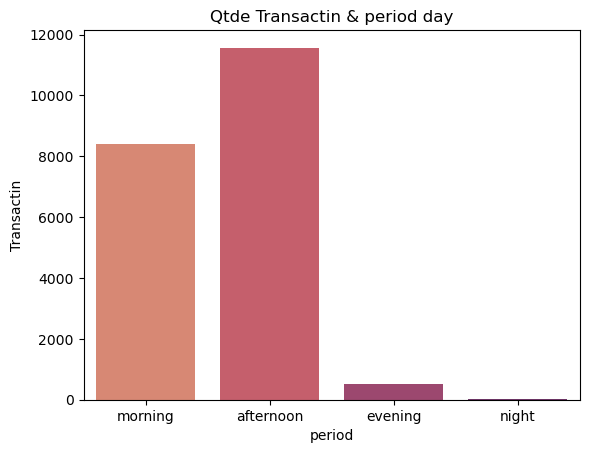

In [638]:
#Transaction by period

ax = sns.countplot(data=df, x="period_day", palette='flare')
ax.set_title("Qtde Transactin & period day")
ax.set_ylabel("Transactin")
ax.set_xlabel("period")


plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_3236\458672102.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.countplot(data=df, x='weekday_weekend', palette='Spectral')


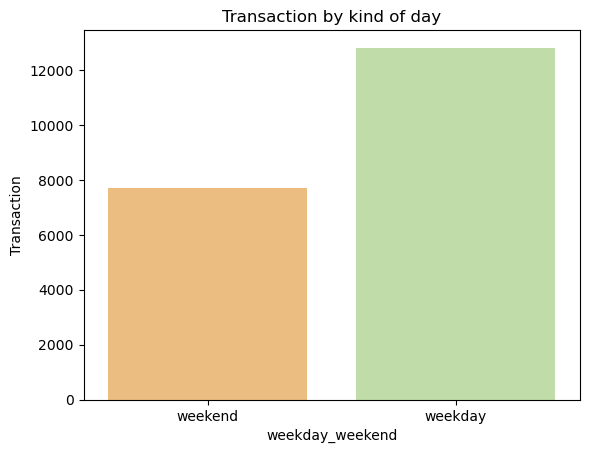

In [640]:
#Transaction by kind of day

ax2 = sns.countplot(data=df, x='weekday_weekend', palette='Spectral')
ax2.set_title("Transaction by kind of day")
ax2.set_ylabel("Transaction")
ax2.set_xlabel("weekday_weekend")


plt.show()

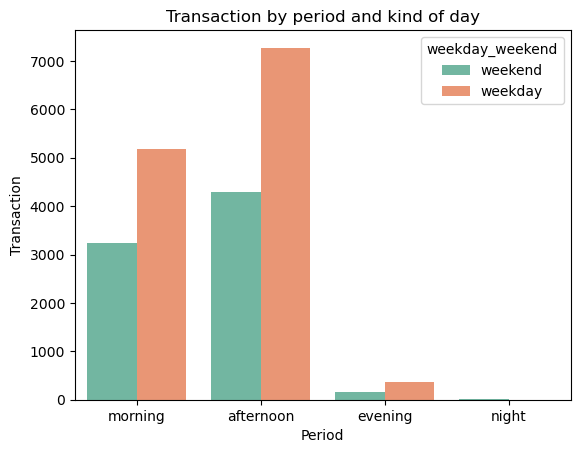

In [642]:
#Transaction by period and kind of day

ax3 = sns.countplot(data=df, x='period_day', hue='weekday_weekend', palette='Set2')
ax3.set_title('Transaction by period and kind of day')
ax3.set_ylabel("Transaction")
ax3.set_xlabel("Period")

plt.show()

In [644]:
#changing the type of Date_time column to datetime

df['date_time'] = pd.to_datetime(df['date_time'])

#Creating hour column 

for i in df['date_time']:
    df['Time'] = i.time()
    df['Date'] = i.date()

df.head()

C:\Users\DELL\AppData\Local\Temp\ipykernel_3236\3829939671.py:3: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date_time'] = pd.to_datetime(df['date_time'])


,Transaction,Item,date_time,period_day,weekday_weekend,Time,Date
0,1,Bread,2016-10-30 09:58:00,morning,weekend,15:04:00,2017-04-09
1,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,15:04:00,2017-04-09
2,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,15:04:00,2017-04-09
3,3,Hot chocolate,2016-10-30 10:07:00,morning,weekend,15:04:00,2017-04-09
4,3,Jam,2016-10-30 10:07:00,morning,weekend,15:04:00,2017-04-09


C:\Users\DELL\AppData\Local\Temp\ipykernel_3236\2262297686.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax4 = sns.countplot(data=df, x='hora', palette='ch:s=.25,rot=-.25')


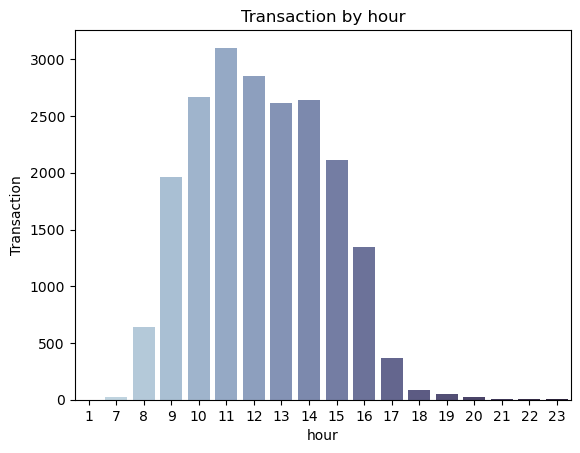

,Transaction,Item,date_time,period_day,weekday_weekend,Time,Date,hora
0,1,Bread,2016-10-30 09:58:00,morning,weekend,15:04:00,2017-04-09,9
1,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,15:04:00,2017-04-09,10
2,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,15:04:00,2017-04-09,10
3,3,Hot chocolate,2016-10-30 10:07:00,morning,weekend,15:04:00,2017-04-09,10
4,3,Jam,2016-10-30 10:07:00,morning,weekend,15:04:00,2017-04-09,10
...,...,...,...,...,...,...,...,...
20502,9682,Coffee,2017-04-09 14:32:00,afternoon,weekend,15:04:00,2017-04-09,14
20503,9682,Tea,2017-04-09 14:32:00,afternoon,weekend,15:04:00,2017-04-09,14
20504,9683,Coffee,2017-04-09 14:57:00,afternoon,weekend,15:04:00,2017-04-09,14
20505,9683,Pastry,2017-04-09 14:57:00,afternoon,weekend,15:04:00,2017-04-09,14


In [645]:
#Transaction by hour

df['hora'] = df['date_time'].dt.hour

ax4 = sns.countplot(data=df, x='hora', palette='ch:s=.25,rot=-.25')
ax4.set_title("Transaction by hour")
ax4.set_xlabel('hour')
ax4.set_ylabel('Transaction')

plt.show()
df

In [646]:
#Transforming the table

def encoder(x):
    if x <= 0:
        return 0
    elif x>= 1:
        return 1


df_v2 = df.groupby(['Transaction', 'Item'])['Item'].count().reset_index(name='Qtde')
df_bask = df_v2.pivot_table(index='Transaction', columns='Item', values='Qtde', aggfunc='sum').fillna(0)
df_bask_final = df_bask.applymap(encoder)

df_bask_final.head()


C:\Users\DELL\AppData\Local\Temp\ipykernel_3236\1789608171.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_bask_final = df_bask.applymap(encoder)


Item,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
Transaction,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Applying the Model

C:\Users\DELL\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_3236\580195784.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax5 = sns.barplot(data=df_apr[:10], x='support', y='itemsets', palette='rocket')


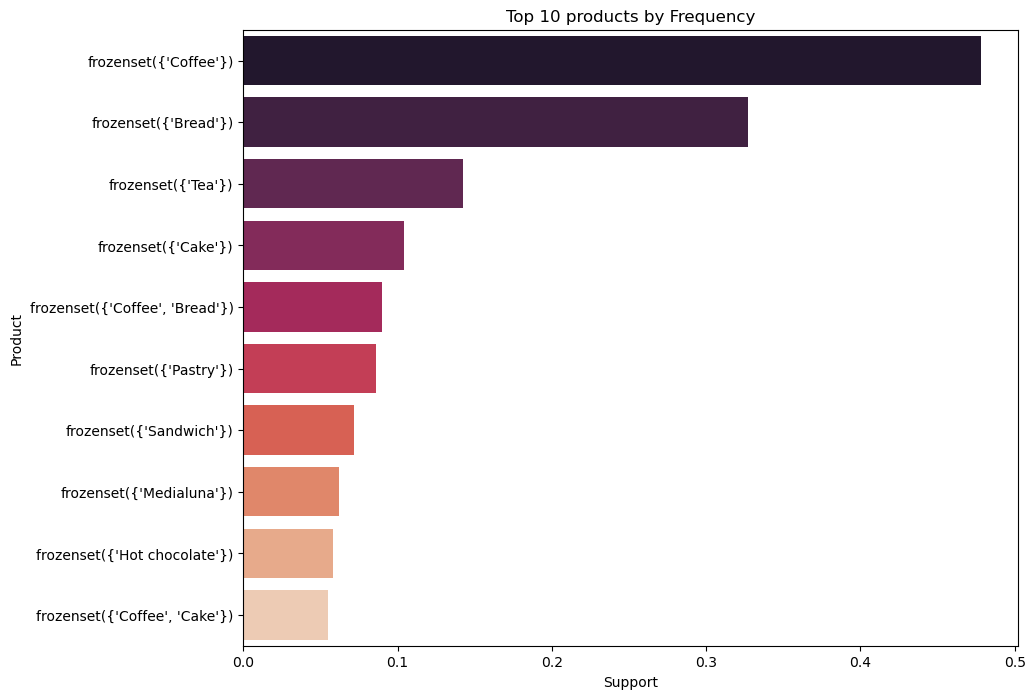

,support,itemsets
6,0.478394,(Coffee)
2,0.327205,(Bread)
26,0.142631,(Tea)
4,0.103856,(Cake)
34,0.090016,"(Coffee, Bread)"


In [648]:
df_apr = apriori(df_bask_final, min_support=0.009, use_colnames=True).sort_values(by='support', ascending=False)

# Top 10 products by frequency of purchase

fig, ax5 = plt.subplots(figsize=(10,8))
ax5 = sns.barplot(data=df_apr[:10], x='support', y='itemsets', palette='rocket')
ax5.set_title("Top 10 products by Frequency")
ax5.set_xlabel("Support")
ax5.set_ylabel("Product")

plt.show()
df_apr.head()

In [649]:
#Applying the association rule

df_assR = association_rules(df_apr, metric='lift', min_threshold=0.01 , num_itemsets=0).sort_values(by='support', ascending=False)
df_assR.sort_values('confidence', ascending = False, inplace = True)
df_assR.reset_index(drop=True, inplace = True)
df_assR.head(50)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Toast),(Coffee),0.033597,0.478394,0.023666,0.704403,1.472431,1.0,0.007593,1.764582,0.332006,0.048464,0.433293,0.376936
1,(Spanish Brunch),(Coffee),0.018172,0.478394,0.010882,0.598837,1.251766,1.0,0.002189,1.300235,0.204851,0.022406,0.230908,0.310792
2,(Medialuna),(Coffee),0.061807,0.478394,0.035182,0.569231,1.189878,1.0,0.005614,1.210871,0.170091,0.069665,0.174148,0.321387
3,(Pastry),(Coffee),0.086107,0.478394,0.047544,0.552147,1.154168,1.0,0.006351,1.164682,0.146161,0.091968,0.141396,0.325764
4,(Alfajores),(Coffee),0.036344,0.478394,0.019651,0.540698,1.130235,1.0,0.002264,1.135648,0.119574,0.039693,0.119446,0.290888
5,(Juice),(Coffee),0.038563,0.478394,0.020602,0.534247,1.116750,1.0,0.002154,1.119919,0.108738,0.041507,0.107078,0.288656
6,(Sandwich),(Coffee),0.071844,0.478394,0.038246,0.532353,1.112792,1.0,0.003877,1.115384,0.109205,0.074701,0.103448,0.306150
7,(Cake),(Coffee),0.103856,0.478394,0.054728,0.526958,1.101515,1.0,0.005044,1.102664,0.102840,0.103745,0.093105,0.320679
8,(Scone),(Coffee),0.034548,0.478394,0.018067,0.522936,1.093107,1.0,0.001539,1.093366,0.088224,0.036507,0.085393,0.280350
9,(Cookies),(Coffee),0.054411,0.478394,0.028209,0.518447,1.083723,1.0,0.002179,1.083174,0.081700,0.055905,0.076787,0.288707


#### **Model evaluation**

### **المعاملات الاكثر شيوعا**

C:\Users\DELL\AppData\Local\Temp\ipykernel_3236\3378324244.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax5 = sns.barplot(data=df[:30], x='support', y='combined', palette='rocket')


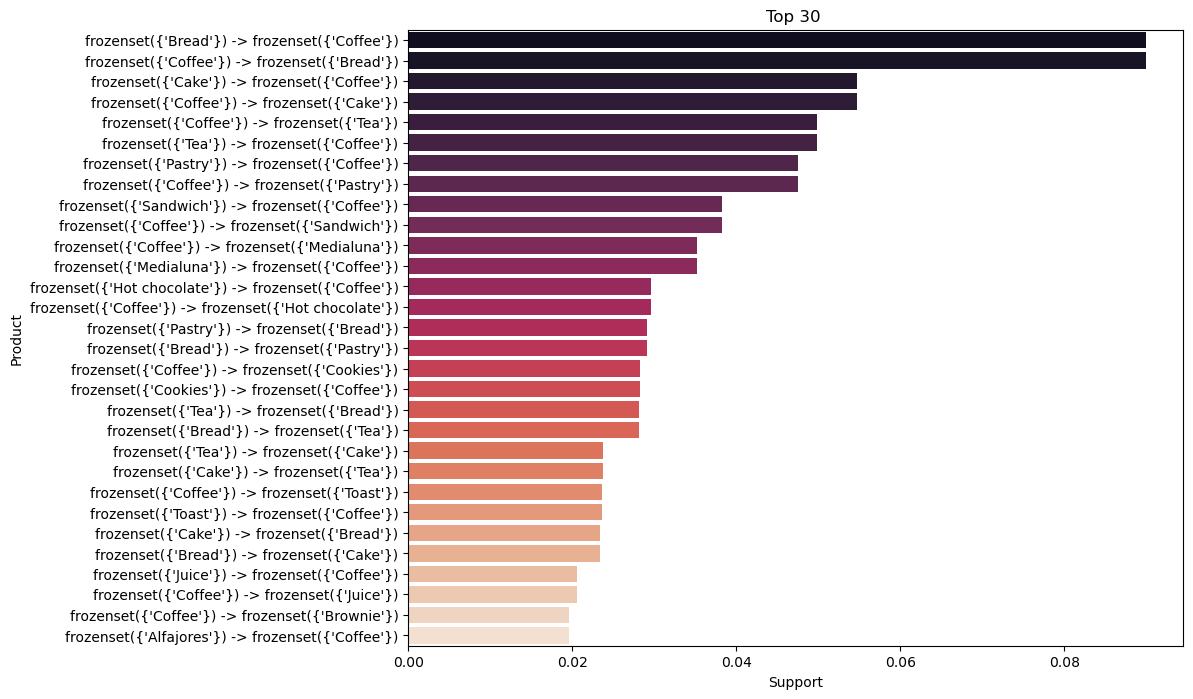

In [745]:
import pandas as pd

# فرضًا أن البيانات موجودة في DataFrame يسمى "df"
df = df_assR.sort_values(by='support', ascending=False)
# دمج العمودين باستخدام دالة apply
def combine_columns(row):
    return f"{row['antecedents']} -> {row['consequents']}"

df['combined'] = df.apply(combine_columns, axis=1)


fig, ax5 = plt.subplots(figsize=(10,8))
ax5 = sns.barplot(data=df[:30], x='support', y='combined', palette='rocket')
ax5.set_title("Top 30 ")
ax5.set_xlabel("Support")
ax5.set_ylabel("Product")
#ax5 = sns.barplot(data=df[:30], x='lift', y='combined', palette='rocket')
plt.show()

#### **lift قياس قوة العلاقة والعلاقات المخفية**

C:\Users\DELL\AppData\Local\Temp\ipykernel_3236\3024650903.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2=sns.barplot(data=df[:30], x='lift', y='combined', palette='rocket')


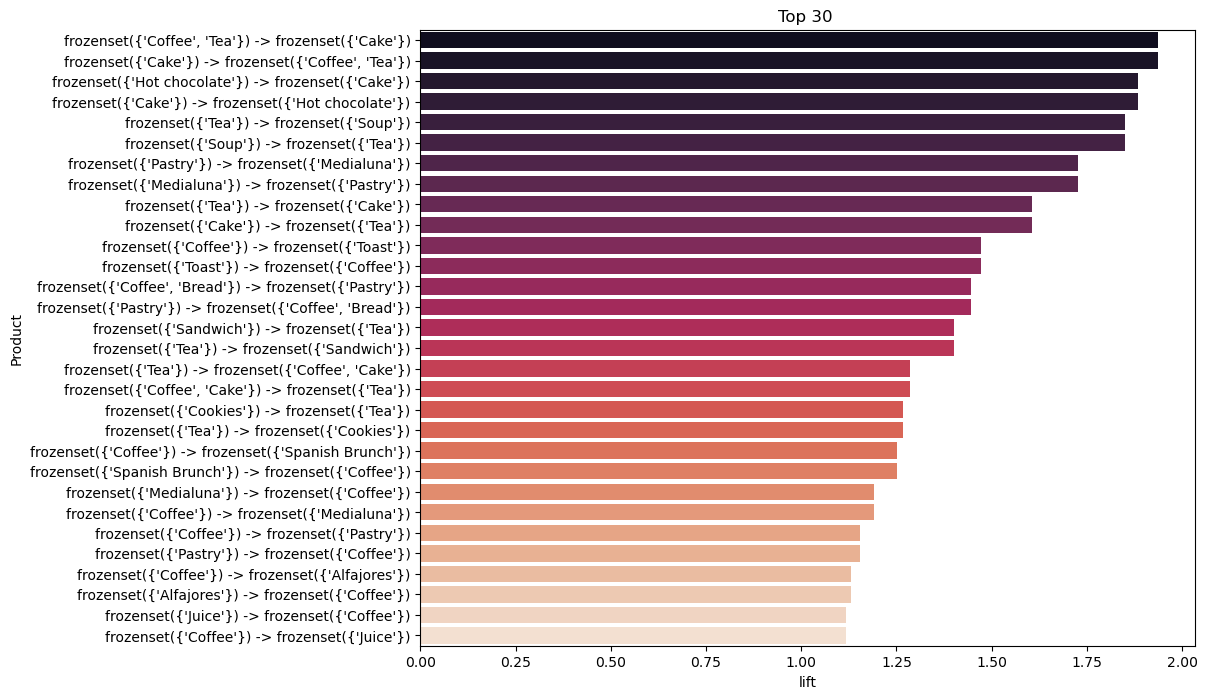

In [740]:
df=df.sort_values(by='lift', ascending=False)
fig, ax2 = plt.subplots(figsize=(10,8))
ax2=sns.barplot(data=df[:30], x='lift', y='combined', palette='rocket')
ax2.set_title("Top 30 ")
ax2.set_xlabel("lift")
ax2.set_ylabel("Product")
plt.show()

#### **confidence احتمالية حدوث النتيجة بالنسبة للشرط**

C:\Users\DELL\AppData\Local\Temp\ipykernel_3236\2731789047.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax5 = sns.barplot(data = df[:30], x='confidence', y='combined', palette='rocket')


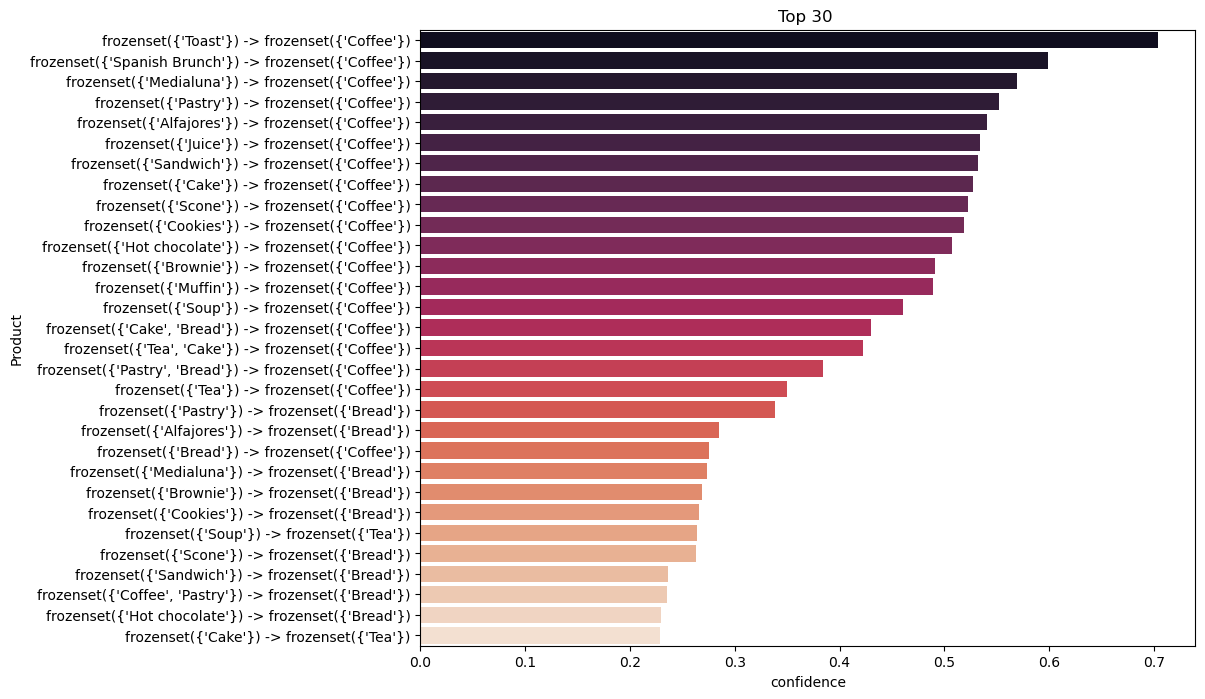

In [741]:
df = df.sort_values(by='confidence', ascending=False)
fig, ax5 = plt.subplots(figsize=(10,8))
ax5 = sns.barplot(data = df[:30], x='confidence', y='combined', palette='rocket')
ax5.set_title("Top 30 ")
ax5.set_xlabel("confidence")
ax5.set_ylabel("Product")
plt.show()

#### ** Network Visualization 
**

In [725]:
import networkx 

Basket_Network2=networkx.DiGraph()

Basket_Network_Data_zip=zip(df_assR["antecedents"],
                            df_assR["consequents"],
                            df_assR["antecedent support"],
                            df_assR["consequent support"],
                            df_assR["support"])

for i in Basket_Network_Data_zip:
    FromItem = str(i[0]).replace("frozenset({'","").replace("'})","").replace("',　'",",") 
    ToItem = str(i[1]).replace("frozenset({'","").replace("'})","").replace("',　'",",") 
    FromWeight = i[2]
    ToWeight = i[3]
    EdgeWeight = i[4]

    Basket_Network2.add_node(FromItem)
    Basket_Network2.add_node(ToItem)
    Basket_Network2.add_edge(FromItem, ToItem, weight=EdgeWeight)


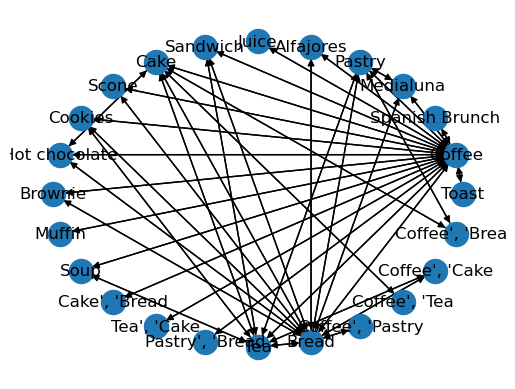

In [727]:
Basket_Network2_Pos=networkx.circular_layout(Basket_Network2)

Basket_Network2_Label={}
for k in Basket_Network2_Pos.keys():
    Basket_Network2_Label[k]=k

networkx.draw_networkx_labels(Basket_Network2, pos=Basket_Network2_Pos, labels=Basket_Network2_Label)
networkx.draw_circular(Basket_Network2)
#networkx.write_gpickle(Basket_Network2, "Basket_Network2")
